# 1.Import Necessary Libraries

In [1]:
import keras
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 2.Data Collection

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# 3.Data Understanding

In [3]:
x_train.shape,y_train.shape

((50000, 32, 32, 3), (50000, 1))

In [4]:
x_test.shape,y_test.shape

((10000, 32, 32, 3), (10000, 1))

In [5]:
assert x_train.shape == (50000, 32, 32, 3)
assert x_test.shape == (10000, 32, 32, 3)
assert y_train.shape == (50000, 1)
assert y_test.shape == (10000, 1)

## 3.1 Let's see one image looks like

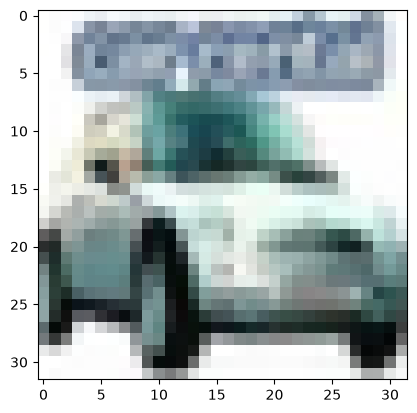

In [6]:
plt.imshow(x_train[40000])

# 4.Data Prepuration 

In [7]:
x_train.min(),x_train.max()

(np.uint8(0), np.uint8(255))

In [8]:
x_test.min(),x_test.max()

(np.uint8(0), np.uint8(255))

In [9]:
x_train = x_train/255.0
x_test  = x_test/255.0

In [10]:
x_train.min(),x_train.max()

(np.float64(0.0), np.float64(1.0))

In [11]:
x_test.min(),x_test.max()

(np.float64(0.0), np.float64(1.0))

In [12]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

# 5.Model Building

In [13]:
from keras.models import Sequential
from keras.layers import Flatten,Dense

In [14]:
model = Sequential()

# Input layer
model.add(layer=Flatten())#multidimenstion

# Hidden layer 1
model.add(Dense(units=512,activation='relu'))

# Hidden layer 2
model.add(Dense(units=256,activation='relu'))

#Outpur layer 
model.add(Dense(units=10,activation='softmax'))

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(optimizer='adam',loss='SparseCategoricalCrossentropy',metrics=["sparse_categorical_accuracy"])

# 6.Model Training

In [17]:
model.fit(x=x_train,y=y_train,batch_size=64,epochs=20,validation_split=0.2)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 1.8961 - sparse_categorical_accuracy: 0.3200 - val_loss: 1.7777 - val_sparse_categorical_accuracy: 0.3635
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 1.6946 - sparse_categorical_accuracy: 0.3916 - val_loss: 1.6925 - val_sparse_categorical_accuracy: 0.3898
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 1.6112 - sparse_categorical_accuracy: 0.4266 - val_loss: 1.6396 - val_sparse_categorical_accuracy: 0.4036
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 1.5517 - sparse_categorical_accuracy: 0.4476 - val_loss: 1.5708 - val_sparse_categorical_accuracy: 0.4467
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 1.5135 - sparse_categorical_accuracy: 0.4600 - val_loss: 1.5952 - val_sparse_categorical_accuracy: 0.4275
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 1.4758 - sparse_categorical_accuracy: 0.4721 - val_loss: 1.5636 - val_sparse_categorical_accuracy:

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (64, 3072)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (64, 512)                   │       1,573,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (64, 256)                   │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (64, 10)                    │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,121,824 (19.54 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,414,550 (13.03 MB)

# 7.Model Evaluation

In [19]:
test_loss,test_accuracy = model.evaluate(x_test,y_test)
print("Test Accuracy",test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.4294 - sparse_categorical_accuracy: 0.5017
Test Accuracy 0.5016999840736389


# 8.Manuval Model Prediction

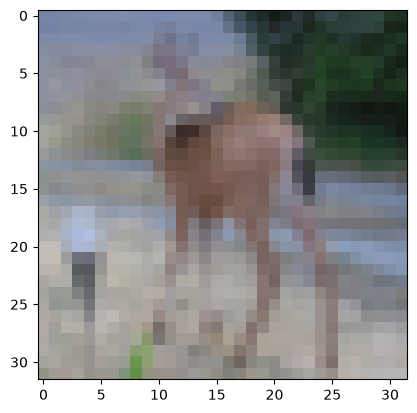

In [38]:
image = x_test[100]
plt.imshow(image)

In [21]:
# ANN expects 2D input:
# (number_of_images, 3072)

image_input = np.expand_dims(image,axis=0)

In [22]:
prediction = model.predict(image_input)
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


array([[0.00603086, 0.01078098, 0.05443861, 0.16209376, 0.10559525,
        0.3270801 , 0.02576041, 0.2900047 , 0.00732525, 0.01089007]],
      dtype=float32)

In [23]:
predict_class = np.argmax(prediction)
predict_class

np.int64(5)

In [46]:
actual_class = y_test[100][0]
actual_class

np.uint8(4)

In [42]:
print(class_names[actual_class])
print(class_names[predict_class])

deer
dog


## 8.1 Diaplay image

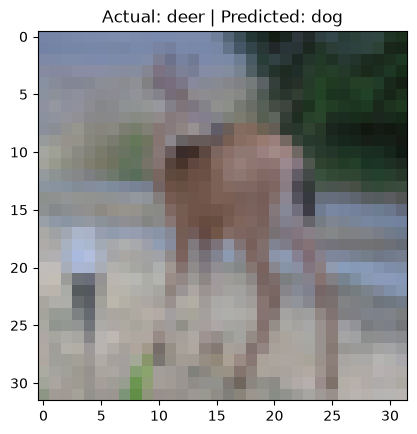

In [43]:
display_image = image.reshape(32,32,3)

plt.imshow(display_image)
plt.title(
    f"Actual: {class_names[actual_class]} | "
    f"Predicted: {class_names[predict_class]}"
)
plt.show()


## Let's take out the model intelligence file

In [63]:
model.save("CIFAR10.h5")

# THE END!!!